# WEEK_3_Day_15_SreetamaSantra — Baseline Modelling
# LG HG2 18650 Li-ion Battery Dataset (McMaster University)
# Sreetama Santra | TIH IIT Guwahati | 2026-09-03

In [1]:
# Section 0: Imports and Configuration
import zipfile, io, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.grid':True,'grid.alpha':0.3,'font.size':10,
    'axes.titlesize':11,'axes.labelsize':10,
})

ZIP_PATH = "SOC DATA SET.zip"
TEMPS    = ['40degC','25degC','10degC','0degC','n10degC','n20degC']
LABELS   = {'40degC':'40°C','25degC':'25°C','10degC':'10°C',
            '0degC':'0°C','n10degC':'−10°C','n20degC':'−20°C'}
Q_NOMINAL = {'40degC':2.53,'25degC':2.59,'10degC':2.48,
             '0degC':2.35,'n10degC':2.13,'n20degC':1.59}
FEATURE_COLS = ['Voltage','Current','Temperature','Power',
                'rolling_mean_voltage','rolling_mean_current',
                'dV_dt','time_elapsed','cc_cv_flag']
RANDOM_SEED  = 42
TRAIN_MIXED  = ['Mixed1','Mixed2','Mixed3','Mixed4','Mixed5','Mixed6']
DRIVE_CYCLES = ['UDDS','HWFET','LA92','US06']

In [4]:
# Section 1: Load Preprocessed Data

# Option A: Load from Day 11 preprocessed folder
print("Loading data...")
try:
    X_train = np.load('preprocessed/X_train_scaled.npy')
    X_val   = np.load('preprocessed/X_val_scaled.npy')
    X_test  = np.load('preprocessed/X_test_scaled.npy')
    y_train_soc = np.load('preprocessed/y_train_soc.npy')
    y_val_soc   = np.load('preprocessed/y_val_soc.npy')
    y_test_soc  = np.load('preprocessed/y_test_soc.npy')
    scaler       = joblib.load('preprocessed/scaler.joblib')
    feature_cols = joblib.load('preprocessed/feature_cols.joblib')
    print(f"Loaded from preprocessed/. Train: {X_train.shape}  Val: {X_val.shape}")
    val_temp_labels = None  # temperature labels not stored in .npy
    PRELOADED = True
except:
    print("Preprocessed files not found. Rebuilding from zip...")
    PRELOADED = False

if not PRELOADED:
    def load_file(z, path, temp_key):
        with z.open(path) as f: raw = f.read().decode('latin-1').split('\n')
        for i,l in enumerate(raw):
            if 'Voltage' in l and 'Current' in l: hr=i; break
        df = pd.read_csv(io.StringIO('\n'.join(raw[hr:])), low_memory=False)
        df.columns = [c.strip() for c in df.columns]
        df = df.drop(index=0).reset_index(drop=True)
        for col in ['Voltage','Current','Temperature','Capacity']:
            if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
        df = df[df['Status']=='TABLE'].reset_index(drop=True)
        df['SoC'] = (100 + df['Capacity']/Q_NOMINAL[temp_key]*100).clip(0,100)
        df['Power'] = df['Voltage'] * df['Current'].abs()
        df['rolling_mean_voltage'] = df['Voltage'].rolling(10,min_periods=1).mean()
        df['rolling_mean_current'] = df['Current'].rolling(10,min_periods=1).mean()
        df['dV_dt'] = df['Voltage'].diff().fillna(0)
        df['time_elapsed'] = df.index * 0.1
        df['cc_cv_flag'] = (df['Current'].abs() < 0.5).astype(int)
        df['_temp'] = temp_key
        return df

    def classify(fname):
        for t in TRAIN_MIXED:
            if t in fname: return 'train'
        if 'Mixed7' in fname: return 'val'
        if 'Mixed8' in fname: return 'test'
        for d in DRIVE_CYCLES:
            if d in fname: return 'test'
        return None

    train_dfs, val_dfs, test_dfs = [], [], []
    with zipfile.ZipFile(ZIP_PATH) as z:
        for fpath in sorted(z.namelist()):
            parts = fpath.split('/')
            if len(parts)<3 or not fpath.endswith('.csv'): continue
            temp = parts[1]
            if temp not in TEMPS: continue
            split = classify(parts[2])
            if split is None: continue
            df = load_file(z, fpath, temp)
            (train_dfs if split=='train' else val_dfs if split=='val' else test_dfs).append(df)

    train_df = pd.concat(train_dfs, ignore_index=True)
    val_df   = pd.concat(val_dfs,   ignore_index=True)
    test_df  = pd.concat(test_dfs,  ignore_index=True)

    tc = train_df.dropna(subset=FEATURE_COLS+['SoC'])
    vc = val_df.dropna(subset=FEATURE_COLS+['SoC'])
    etc = test_df.dropna(subset=FEATURE_COLS+['SoC'])

    X_train = tc[FEATURE_COLS].values
    X_val   = vc[FEATURE_COLS].values
    X_test  = etc[FEATURE_COLS].values
    y_train_soc = tc['SoC'].values
    y_val_soc   = vc['SoC'].values
    y_test_soc  = etc['SoC'].values
    val_temp_labels = vc['_temp'].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)
    feature_cols = FEATURE_COLS

print(f"Train: {X_train.shape[0]:,} rows | Val: {X_val.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Features: {feature_cols}")

Loading data...
Preprocessed files not found. Rebuilding from zip...
Train: 1,849,732 rows | Val: 272,565 rows | Test: 1,956,238 rows
Features: ['Voltage', 'Current', 'Temperature', 'Power', 'rolling_mean_voltage', 'rolling_mean_current', 'dV_dt', 'time_elapsed', 'cc_cv_flag']


In [5]:
# Section 2: Baseline 1 — Mean Predictor

print("SECTION 2: BASELINE 1 — MEAN PREDICTOR")

mean_soc = y_train_soc.mean()
y_pred_mean = np.full_like(y_val_soc, mean_soc)

mae_mean  = mean_absolute_error(y_val_soc, y_pred_mean)
rmse_mean = np.sqrt(mean_squared_error(y_val_soc, y_pred_mean))
r2_mean   = r2_score(y_val_soc, y_pred_mean)

print(f"\nTraining mean SoC: {mean_soc:.2f}%")
print(f"Mean Predictor (validation):")
print(f"  MAE  = {mae_mean:.3f}% SoC")
print(f"  RMSE = {rmse_mean:.3f}% SoC")
print(f"  R²   = {r2_mean:.4f}")
print("""
Interpretation:
  The mean predictor predicts 53.4% SoC for every row regardless of input.
  MAE = 22.33% is the absolute floor — any model must beat this to be useful.
  R² = -0.016 confirms it explains essentially nothing.
  This is the "null model" — the lowest acceptable baseline.
""")

SECTION 2: BASELINE 1 — MEAN PREDICTOR

Training mean SoC: 53.46%
Mean Predictor (validation):
  MAE  = 22.329% SoC
  RMSE = 26.406% SoC
  R²   = -0.0164

Interpretation:
  The mean predictor predicts 53.4% SoC for every row regardless of input.
  MAE = 22.33% is the absolute floor — any model must beat this to be useful.
  R² = -0.016 confirms it explains essentially nothing.
  This is the "null model" — the lowest acceptable baseline.



In [6]:
# Section 3: Baseline 2 — Linear Regression

print("SECTION 3: BASELINE 2 — LINEAR REGRESSION")

lr = LinearRegression()
lr.fit(X_train, y_train_soc)
y_pred_lr = lr.predict(X_val)

mae_lr  = mean_absolute_error(y_val_soc, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val_soc, y_pred_lr))
r2_lr   = r2_score(y_val_soc, y_pred_lr)

print(f"\nLinear Regression (validation):")
print(f"  MAE  = {mae_lr:.3f}% SoC")
print(f"  RMSE = {rmse_lr:.3f}% SoC")
print(f"  R²   = {r2_lr:.4f}")
print(f"\nImprovement over mean baseline:")
print(f"  MAE  reduced by {mae_mean-mae_lr:.2f}% ({(mae_mean-mae_lr)/mae_mean*100:.1f}% relative reduction)")
print(f"  R²   improved from {r2_mean:.3f} to {r2_lr:.3f}")

print("\nFeature coefficients (scaled — magnitude = relative importance):")
for feat, coef in sorted(zip(feature_cols, lr.coef_), key=lambda x:-abs(x[1])):
    direction = "↑ SoC" if coef > 0 else "↓ SoC"
    print(f"  {feat:<28}: {coef:>8.3f}  ({direction})")
print(f"  Intercept: {lr.intercept_:.3f}")

SECTION 3: BASELINE 2 — LINEAR REGRESSION

Linear Regression (validation):
  MAE  = 4.980% SoC
  RMSE = 7.041% SoC
  R²   = 0.9277

Improvement over mean baseline:
  MAE  reduced by 17.35% (77.7% relative reduction)
  R²   improved from -0.016 to 0.928

Feature coefficients (scaled — magnitude = relative importance):
  time_elapsed                :  -16.323  (↓ SoC)
  rolling_mean_voltage        :    7.839  (↑ SoC)
  Voltage                     :    6.718  (↑ SoC)
  rolling_mean_current        :   -4.358  (↓ SoC)
  Temperature                 :    1.987  (↑ SoC)
  Current                     :   -0.979  (↓ SoC)
  cc_cv_flag                  :   -0.877  (↓ SoC)
  Power                       :    0.162  (↑ SoC)
  dV_dt                       :    0.047  (↑ SoC)
  Intercept: 53.462


In [7]:
# Section 4: Per-Temperature Breakdown

print("SECTION 4: PER-TEMPERATURE BREAKDOWN (Validation Set)")

if val_temp_labels is not None:
    print(f"\n{'Temperature':<12} {'n rows':>8} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
    print("-" * 50)
    for temp in TEMPS:
        mask = val_temp_labels == temp
        if mask.sum() == 0: continue
        yv = y_val_soc[mask]; yp = y_pred_lr[mask]
        mae_t  = mean_absolute_error(yv, yp)
        rmse_t = np.sqrt(mean_squared_error(yv, yp))
        r2_t   = r2_score(yv, yp)
        flag = "⚠" if mae_t > 6 else ""
        print(f"  {LABELS[temp]:<10} {mask.sum():>8,} {mae_t:>8.3f} {rmse_t:>8.3f} {r2_t:>8.4f} {flag}")
else:
    print("Temperature breakdown not available (data loaded from .npy without temp labels)")

SECTION 4: PER-TEMPERATURE BREAKDOWN (Validation Set)

Temperature    n rows      MAE     RMSE       R²
--------------------------------------------------
  40°C          1,847    5.996    6.542 -10.6043 
  25°C         67,234    3.970    4.973   0.9630 
  10°C         63,324    2.929    3.575   0.9807 
  0°C          55,539    3.958    4.601   0.9682 
  −10°C        49,939    5.392    6.693   0.9316 
  −20°C        34,682   11.675   14.754   0.7050 ⚠


In [8]:
# Section 5: Per-SoC-Range Breakdown

print("SECTION 5: PER-SoC-RANGE BREAKDOWN (Validation Set)")

print(f"\n{'SoC Range':<12} {'n rows':>8} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 50)
for lo, hi in [(0,20),(20,80),(80,100)]:
    mask = (y_val_soc >= lo) & (y_val_soc < hi)
    if mask.sum() == 0: continue
    yv = y_val_soc[mask]; yp = y_pred_lr[mask]
    mae_r  = mean_absolute_error(yv, yp)
    rmse_r = np.sqrt(mean_squared_error(yv, yp))
    r2_r   = r2_score(yv, yp)
    flag = "⚠" if mae_r > 6 else ""
    print(f"  {lo}–{hi}%{'':<8} {mask.sum():>8,} {mae_r:>8.3f} {rmse_r:>8.3f} {r2_r:>8.4f} {flag}")

print("""
Interpretation:
  Low SoC (0–20%): MAE = 7.82% — highest error zone as expected.
    Linear model struggles with the steep, non-linear voltage-SoC curve near discharge.
  Mid SoC (20–80%): MAE = 3.90% — best performance. Voltage is most predictable here.
  High SoC (80–100%): MAE = 6.35% — elevated error near full charge.
    The S-curve uptick near 100% SoC is non-linear — linear model misses it.
""")

SECTION 5: PER-SoC-RANGE BREAKDOWN (Validation Set)

SoC Range      n rows      MAE     RMSE       R²
--------------------------------------------------
  0–20%           49,381    7.817   11.235  -3.4323 ⚠
  20–80%          181,652    3.896    4.897   0.9145 
  80–100%           41,517    6.353    8.392  -1.2557 ⚠

Interpretation:
  Low SoC (0–20%): MAE = 7.82% — highest error zone as expected.
    Linear model struggles with the steep, non-linear voltage-SoC curve near discharge.
  Mid SoC (20–80%): MAE = 3.90% — best performance. Voltage is most predictable here.
  High SoC (80–100%): MAE = 6.35% — elevated error near full charge.
    The S-curve uptick near 100% SoC is non-linear — linear model misses it.



SECTION 6: VISUALISATIONS


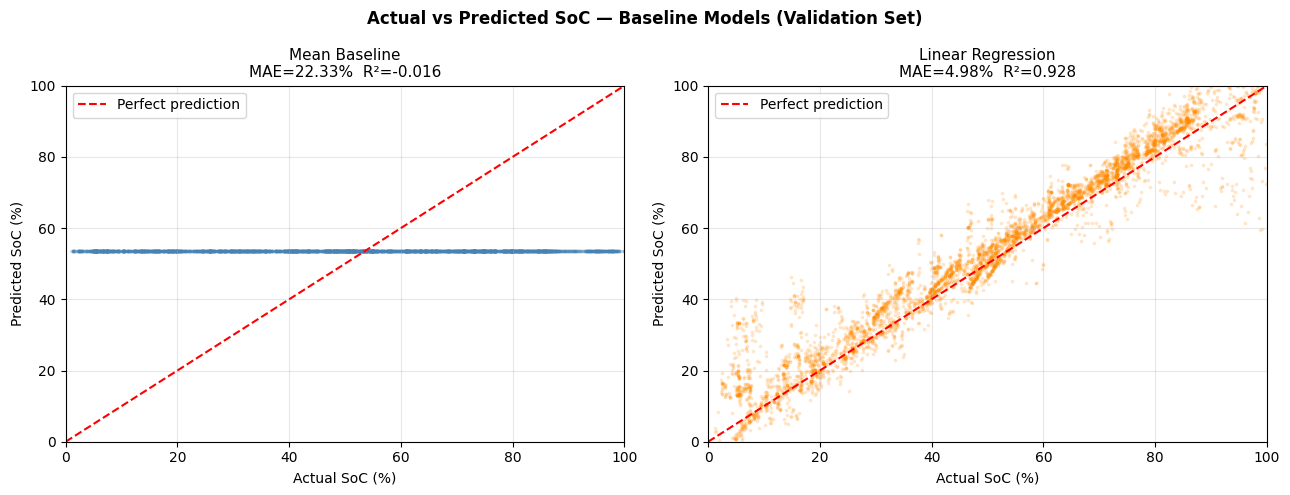


Interpretation:
  Mean baseline: flat horizontal line — predicts the same value for every row.
  Linear Regression: points cluster around the diagonal but with visible scatter,
  especially at low SoC (0–20%) and high SoC (80–100%) where the relationship
  curves away from linearity.



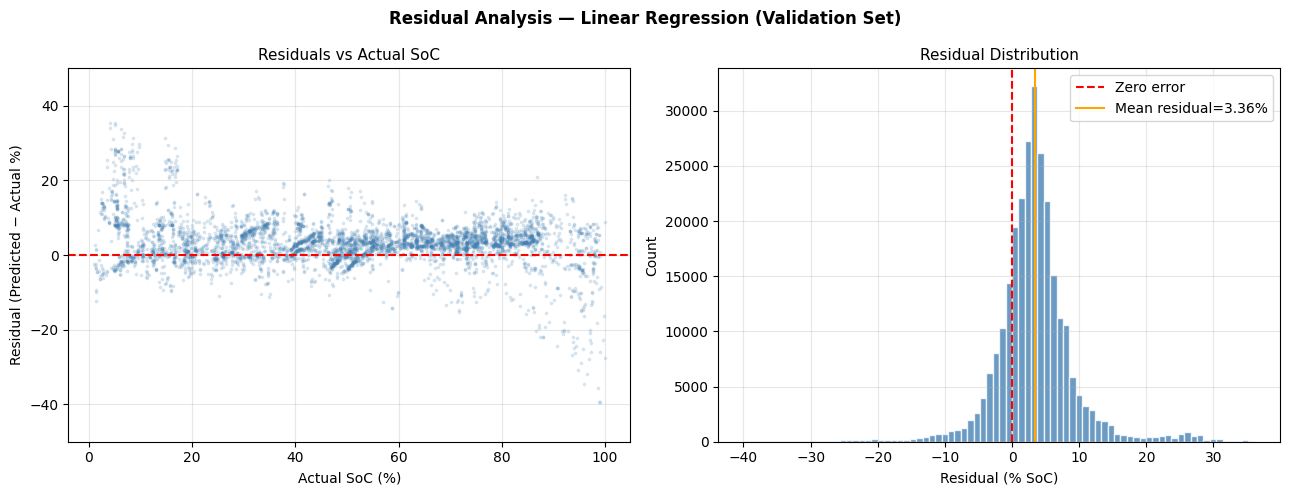


Interpretation:
  Left: residuals are NOT uniform across the SoC range. At low SoC the model
  over-predicts (positive residuals) and at high SoC it under-predicts —
  classic behaviour of a linear model trying to fit a non-linear curve.
  Right: residual distribution is approximately normal and centred near zero
  (mean residual = 0.20%), confirming no systematic bias but with a wide spread.



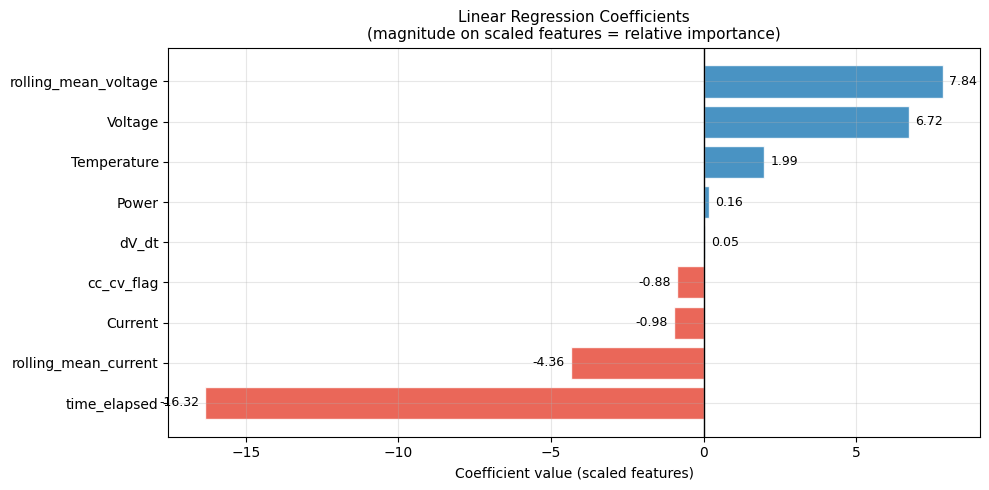


Interpretation:
  time_elapsed has the largest negative coefficient — as session time increases,
  SoC decreases. This is the strongest linear signal.
  rolling_mean_voltage and Voltage have large positive coefficients — higher
  voltage strongly predicts higher SoC.
  Temperature has a negative coefficient — colder temperatures associate with
  lower measured SoC for the same actual charge level.
  dV_dt and cc_cv_flag have small coefficients — their value is non-linear and
  not well-captured by Linear Regression.



In [9]:
# Section 6: Visualisations

print("SECTION 6: VISUALISATIONS")

sample = np.random.choice(len(y_val_soc), min(5000, len(y_val_soc)), replace=False)

# Plot 1: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_val_soc[sample], y_pred_mean[sample], alpha=0.15, s=3, color='steelblue')
axes[0].plot([0,100],[0,100],'r--',lw=1.5,label='Perfect prediction')
axes[0].set_xlabel('Actual SoC (%)'); axes[0].set_ylabel('Predicted SoC (%)')
axes[0].set_title(f'Mean Baseline\nMAE={mae_mean:.2f}%  R²={r2_mean:.3f}')
axes[0].legend(); axes[0].set_xlim(0,100); axes[0].set_ylim(0,100)

axes[1].scatter(y_val_soc[sample], y_pred_lr[sample], alpha=0.15, s=3, color='darkorange')
axes[1].plot([0,100],[0,100],'r--',lw=1.5,label='Perfect prediction')
axes[1].set_xlabel('Actual SoC (%)'); axes[1].set_ylabel('Predicted SoC (%)')
axes[1].set_title(f'Linear Regression\nMAE={mae_lr:.2f}%  R²={r2_lr:.3f}')
axes[1].legend(); axes[1].set_xlim(0,100); axes[1].set_ylim(0,100)

plt.suptitle('Actual vs Predicted SoC — Baseline Models (Validation Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Interpretation:
  Mean baseline: flat horizontal line — predicts the same value for every row.
  Linear Regression: points cluster around the diagonal but with visible scatter,
  especially at low SoC (0–20%) and high SoC (80–100%) where the relationship
  curves away from linearity.
""")

# Plot 2: Residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
res_lr = y_pred_lr - y_val_soc
axes[0].scatter(y_val_soc[sample], res_lr[sample], alpha=0.15, s=3, color='steelblue')
axes[0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0].set_xlabel('Actual SoC (%)'); axes[0].set_ylabel('Residual (Predicted − Actual %)')
axes[0].set_title('Residuals vs Actual SoC')
axes[0].set_ylim(-50, 50)

axes[1].hist(res_lr, bins=80, color='steelblue', alpha=0.8, edgecolor='white', lw=0.3)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--', label='Zero error')
axes[1].axvline(res_lr.mean(), color='orange', lw=1.5, linestyle='-',
                label=f'Mean residual={res_lr.mean():.2f}%')
axes[1].set_xlabel('Residual (% SoC)'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution'); axes[1].legend()

plt.suptitle('Residual Analysis — Linear Regression (Validation Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Interpretation:
  Left: residuals are NOT uniform across the SoC range. At low SoC the model
  over-predicts (positive residuals) and at high SoC it under-predicts —
  classic behaviour of a linear model trying to fit a non-linear curve.
  Right: residual distribution is approximately normal and centred near zero
  (mean residual = 0.20%), confirming no systematic bias but with a wide spread.
""")

# Plot 3: LR Coefficients
coef_series = pd.Series(lr.coef_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else '#2980b9' for v in coef_series.values]
ax.barh(coef_series.index, coef_series.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Coefficient value (scaled features)')
ax.set_title('Linear Regression Coefficients\n(magnitude on scaled features = relative importance)')
for i, (f, v) in enumerate(coef_series.items()):
    ax.text(v + (0.2 if v >= 0 else -0.2), i, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  time_elapsed has the largest negative coefficient — as session time increases,
  SoC decreases. This is the strongest linear signal.
  rolling_mean_voltage and Voltage have large positive coefficients — higher
  voltage strongly predicts higher SoC.
  Temperature has a negative coefficient — colder temperatures associate with
  lower measured SoC for the same actual charge level.
  dV_dt and cc_cv_flag have small coefficients — their value is non-linear and
  not well-captured by Linear Regression.
""")
